# Population Density Data: Convert, Clean & Annual-Expansion Pipeline

**Purpose:** Process the raw gridded population-density NetCDF (2000–2020, 5-year snapshots),
validate spatial alignment with the weather reanalysis grid, apply a vegetation mask to
remove non-combustible cells, and expand the 5-year census snapshots into a continuous
annual time series (1994–2020).

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Inspect & Convert** | Load `.nc`, inspect dimensions, convert to DataFrame, QA grid alignment, check missing rates |
| **B. Vegetation Filter** | Inner-join with combustible-vegetation grid; overwrite parquet |
| **C. Annual Expansion** | Map 5-year census years → nearest snapshot; broadcast to every analysis year (1994–2020) |

**Inputs:**
- `Population_Data/population_density.2000.2020.CA.nc` — gridded population density (census years)
- `Clean_Data/Veg_Data/lon_lat_pair_weather_match_veg_v2.parquet` — vegetation-filtered grid
- `Clean_Data/Weather_Data/Extended_Weather_Data/wind_speed.parquet` — reference weather grid

**Outputs:**
- `Clean_Data/Population/population_density.parquet` — vegetation-filtered, 5-year snapshots
- `Clean_Data/Population/population_density_yearly_1994_2020.parquet` — annual series

## 0. Configuration

Centralized path configuration — **edit this cell only** to adapt to your local setup.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input paths
POPULATION_DATA_DIR = os.path.join(PROJECT_ROOT, "Population_Data")

# Reference grid (any single-day parquet from the weather pipeline)
WEATHER_REF_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Weather_Data",
    "Extended_Weather_Data", "wind_speed.parquet"
)

# Vegetation v2 grid produced by 00_Veg_Weather_Grid_Match.ipynb
VEG_V2_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Veg_Data",
    "lon_lat_pair_weather_match_veg_v2.parquet"
)

# Output directory
POPULATION_CLEAN_DIR = os.path.join(PROJECT_ROOT, "Clean_Data", "Population")
os.makedirs(POPULATION_CLEAN_DIR, exist_ok=True)

# Year expansion range
START_YEAR = 1994
END_YEAR   = 2020

print(f"Population data dir : {POPULATION_DATA_DIR}")
print(f"Output dir          : {POPULATION_CLEAN_DIR}")
print(f"Veg v2 path         : {VEG_V2_PATH}")
print(f"Weather ref path    : {WEATHER_REF_PATH}")

Population data dir : E:\zcao\CA_Wildfire\Population_Data
Output dir          : E:\zcao\CA_Wildfire\Clean_Data\Population
Veg v2 path         : E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\lon_lat_pair_weather_match_veg_v2.parquet
Weather ref path    : E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Extended_Weather_Data\wind_speed.parquet


## 1. Environment Setup

In [2]:
import sys
import gc
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm

gc.collect()

print(f"Python  : {sys.version.split('|')[0].strip()}")
print(f"pandas  : {pd.__version__}")
print(f"xarray  : {xr.__version__}")
print(f"numpy   : {np.__version__}")
print(f"pyproj  : {pyproj.__version__}")
print(f"geopandas: {gpd.__version__}")

Python  : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas  : 2.2.2
xarray  : 2024.7.0
numpy   : 1.24.4
pyproj  : 3.6.1
geopandas: 0.14.3


---

# Phase A: Inspect & Convert Population NetCDF

Read the raw NetCDF file, inspect its structure, convert to a flat DataFrame,
verify spatial alignment with the weather grid, and check missing rates.

## 2. Discover Input Files

List all `.nc` files in the population data directory.
The dataset ships as a single file covering census years 2000, 2005, 2010, 2015, 2020.

In [3]:
all_files = os.listdir(POPULATION_DATA_DIR)
nc_files  = [f for f in all_files if f.endswith('.nc')]

print(f"Total files in dir : {len(all_files)}")
print(f"NetCDF (.nc) files : {len(nc_files)}")
for f in nc_files:
    print(f"  {f}")

Total files in dir : 21
NetCDF (.nc) files : 1
  population_density.2000.2020.CA.nc


In [4]:
file = nc_files[0]
print(f"Using: {file}")

Using: population_density.2000.2020.CA.nc


## 3. Load & Inspect Dataset

Open the NetCDF with `xarray`. The `.squeeze()` call drops any length-1 dimensions
that would otherwise complicate the DataFrame conversion.

In [5]:
population_ds = xr.open_dataset(os.path.join(POPULATION_DATA_DIR, file)).squeeze()
population_ds

<xarray.Dataset> Size: 32MB
Dimensions:             (time: 5, lat: 585, lon: 1386)
Coordinates:
  * time                (time) datetime64[ns] 40B 2000-01-01 ... 2020-01-01
  * lat                 (lat) float64 5kB 25.07 25.11 25.15 ... 49.32 49.36 49.4
  * lon                 (lon) float64 11kB -124.8 -124.7 -124.7 ... -67.1 -67.06
Data variables:
    population_density  (time, lat, lon) float64 32MB ...

## 4. Convert to DataFrame

Flatten the 3-D (time × lat × lon) array into a tidy DataFrame.
Check the available time steps and spot-check the first few rows.

In [6]:
population_dat = population_ds.to_dataframe().reset_index()
print(f"Shape: {population_dat.shape}")
print(f"Columns: {list(population_dat.columns)}")

Shape: (4054050, 4)
Columns: ['time', 'lat', 'lon', 'population_density']


In [7]:
population_dat.head()

,time,lat,lon,population_density
0,2000-01-01,25.066667,-124.766667,NaN
1,2000-01-01,25.066667,-124.725000,NaN
2,2000-01-01,25.066667,-124.683333,NaN
3,2000-01-01,25.066667,-124.641667,NaN
4,2000-01-01,25.066667,-124.600000,NaN


In [8]:
# Confirm the 5 census snapshots are present
print("Available time steps:")
print(population_dat['time'].unique())

Available time steps:
<DatetimeArray>
['2000-01-01 00:00:00', '2005-01-01 00:00:00', '2010-01-01 00:00:00',
 '2015-01-01 00:00:00', '2020-01-01 00:00:00']
Length: 5, dtype: datetime64[ns]


## 5. Spatial QA: Verify Grid Alignment with Weather Data

The population grid must be a **superset** of the weather grid so that every
weather grid cell can be matched to a population estimate.
We perform an inner join and check that no weather cells are lost.

In [9]:
population_lon_lat = population_dat[['lon', 'lat']].drop_duplicates()
print(f"Population grid cells: {len(population_lon_lat):,}")

Population grid cells: 810,810


In [10]:
# Load a single day from the reference weather file to extract the grid
reference_weather = pd.read_parquet(WEATHER_REF_PATH)
reference_weather = reference_weather[reference_weather['day'] == '1998-01-01']
reference_grid    = reference_weather[['lon', 'lat']].drop_duplicates()
print(f"Weather reference grid cells: {len(reference_grid):,}")

Weather reference grid cells: 61,404


In [11]:
test_merge = population_lon_lat.merge(reference_grid, on=['lon', 'lat'], how='inner')

if test_merge.shape[0] == reference_grid.shape[0]:
    print(f"Grid alignment OK — all {len(reference_grid):,} weather cells covered.")
else:
    n_missing = reference_grid.shape[0] - test_merge.shape[0]
    print(f"WARNING: {n_missing:,} weather cells not found in population grid.")
    print(f"  Weather grid: {reference_grid.shape[0]:,} | Matched: {test_merge.shape[0]:,}")

Grid alignment OK — all 61,404 weather cells covered.


## 6. Missing Rate (Raw Data)

Check the fraction of `NaN` values in `population_density` for each census year.
A consistent missing rate across years indicates stable spatial coverage.

In [12]:
missing_by_year = (
    population_dat
    .groupby('time')['population_density']
    .apply(lambda x: x.isnull().mean())
    .rename('missing_rate')
    .reset_index()
)
print("Missing rate by census year:")
print(missing_by_year.to_string(index=False))

Missing rate by census year:
      time  missing_rate
2000-01-01      0.943912
2005-01-01      0.943912
2010-01-01      0.943912
2015-01-01      0.943912
2020-01-01      0.943912


## 7. Visualize: Population Density (Year 2000)

Scatter the year-2000 snapshot to confirm spatial coverage and data quality
before saving. The color scale uses `viridis` to highlight density gradients.

Year-2000 snapshot: 810,810 grid cells


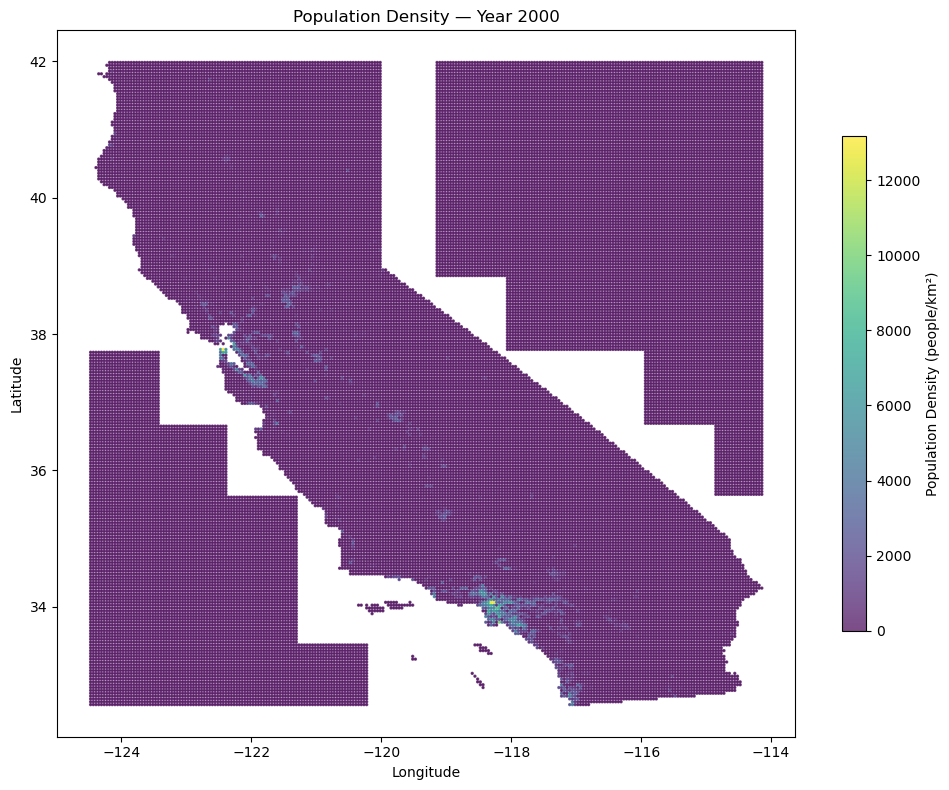

In [13]:
pop_2000 = population_dat[population_dat['time'] == '2000-01-01T00:00:00']
print(f"Year-2000 snapshot: {pop_2000.shape[0]:,} grid cells")

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    pop_2000['lon'], pop_2000['lat'],
    c=pop_2000['population_density'], cmap='viridis', s=2, alpha=0.7
)
fig.colorbar(sc, ax=ax, label='Population Density (people/km²)', shrink=0.7)
ax.set_title('Population Density — Year 2000')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### Save Phase A Output

Save the full (unfiltered) population DataFrame as a parquet file.
Phase B will overwrite this file after applying the vegetation filter.

In [14]:
phase_a_file = file.split('.')[0] + '.parquet'   # 'population_density.parquet'
phase_a_path = os.path.join(POPULATION_CLEAN_DIR, phase_a_file)

population_dat.to_parquet(phase_a_path, index=False)

print(f"Saved -> {phase_a_path}")
print(f"File size: {os.path.getsize(phase_a_path) / 1e6:.1f} MB")

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Population\population_density.parquet
File size: 1.9 MB


---

# Phase B: Vegetation Filter

Inner-join the population data with the combustible-vegetation grid
(produced by `00_Veg_Weather_Grid_Match.ipynb`), removing grid cells
classified as **Water**, **Urban**, or **Agriculture**.

## 8. Load & Filter Vegetation Grid

Load the v2 vegetation lookup and exclude the three non-combustible classes.
The surviving cells define the spatial domain for all downstream modeling.

In [15]:
# Free memory from Phase A
gc.collect()
for var in list(globals().keys()):
    if isinstance(globals().get(var), pd.DataFrame) and var not in ('veg_data',):
        del globals()[var]
gc.collect()

0

In [16]:
veg_data = pd.read_parquet(VEG_V2_PATH)

veg_all      = veg_data.copy()
veg_filtered = veg_data[~veg_data['veg'].str.contains('Water|Urban|Agriculture')]

print(f"Vegetation grid (all types)    : {len(veg_all):,} cells")
print(f"Vegetation grid (combustible)  : {len(veg_filtered):,} cells")
print(f"Removed (Water/Urban/Agri)     : {len(veg_all) - len(veg_filtered):,} cells")

Vegetation grid (all types)    : 17,714 cells
Vegetation grid (combustible)  : 14,394 cells
Removed (Water/Urban/Agri)     : 3,320 cells


In [17]:
# Confirm unique lon/lat pairs to use as the join key
filter_keys = veg_filtered[['lon', 'lat']].drop_duplicates()
print(f"Unique combustible grid cells: {len(filter_keys):,}")

Unique combustible grid cells: 14,394


## 9. Apply Vegetation Filter to Population Data

Load the Phase A parquet, inner-join with the combustible-vegetation keys,
and overwrite the same file with the filtered result.

> **Note:** The output file name is unchanged (`population_density.parquet`) so
> Phase C can load it without modification.

In [18]:
pop_file = 'population_density.parquet'
pop_path = os.path.join(POPULATION_CLEAN_DIR, pop_file)

print(f"Processing started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

dat = pd.read_parquet(pop_path)
print(f"Before filter: {dat.shape[0]:,} rows")

dat_filtered = dat.merge(filter_keys, on=['lon', 'lat'], how='inner')
print(f"After filter : {dat_filtered.shape[0]:,} rows")
print(f"Reduction    : {(1 - dat_filtered.shape[0]/dat.shape[0])*100:.1f}%")

del dat
gc.collect()

dat_filtered.to_parquet(pop_path, index=False)
print(f"Saved (overwrite) -> {pop_path}")

Processing started: 2026-03-17 13:24:44
Before filter: 4,054,050 rows
After filter : 71,970 rows
Reduction    : 98.2%
Saved (overwrite) -> E:\zcao\CA_Wildfire\Clean_Data\Population\population_density.parquet


### Missing Rate After Vegetation Filter

Verify that the vegetation filter does not introduce additional missing values
or distort the per-year pattern observed in Phase A.

In [19]:
missing_filtered = (
    dat_filtered
    .groupby('time')['population_density']
    .apply(lambda x: x.isnull().mean())
    .rename('missing_rate')
    .reset_index()
)
print("Missing rate by census year (after vegetation filter):")
print(missing_filtered.to_string(index=False))

Missing rate by census year (after vegetation filter):
      time  missing_rate
2000-01-01      0.029874
2005-01-01      0.029874
2010-01-01      0.029874
2015-01-01      0.029874
2020-01-01      0.029874


---

# Phase C: Expand to Annual Resolution (1994–2020)

The raw dataset has only 5 census snapshots (2000, 2005, 2010, 2015, 2020).
We broadcast each snapshot to the analysis years that fall closest to it:

| Analysis Years | Assigned Census Snapshot |
|---------------|-------------------------|
| 1994 – 2004   | 2000                    |
| 2005 – 2009   | 2005                    |
| 2010 – 2014   | 2010                    |
| 2015 – 2019   | 2015                    |
| 2020          | 2020                    |

This produces a yearly panel from 1994 to 2020 at the same spatial resolution.

## 10. Load Vegetation-Filtered Population Data

Reload the veg-filtered parquet (written in Phase B) for the expansion step.
A quick scatter confirms the grid is intact.

In [20]:
dat = pd.read_parquet(os.path.join(POPULATION_CLEAN_DIR, 'population_density.parquet'))

print(f"Shape  : {dat.shape}")
print(f"Columns: {list(dat.columns)}")
print(f"dtypes :\n{dat.dtypes}")

Shape  : (71970, 4)
Columns: ['time', 'lat', 'lon', 'population_density']
dtypes :
time                  datetime64[ns]
lat                          float64
lon                          float64
population_density           float64
dtype: object


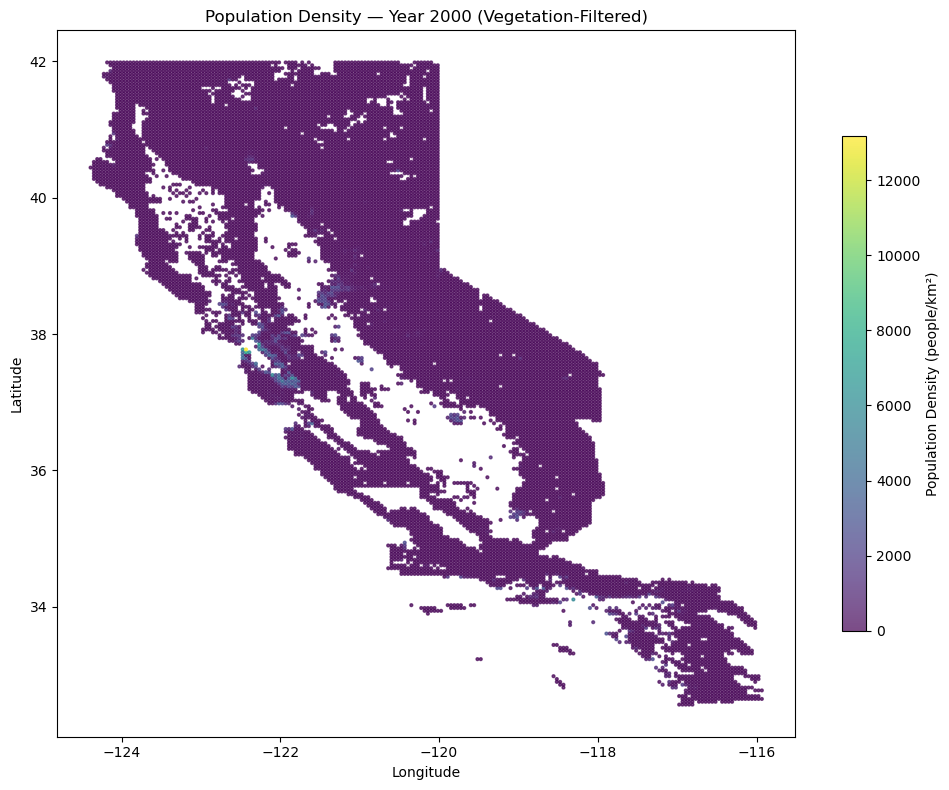

In [21]:
# Sanity-check scatter for the year-2000 snapshot
dat_2000 = dat[dat['time'] == '2000-01-01T00:00:00']

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    dat_2000['lon'], dat_2000['lat'],
    c=dat_2000['population_density'], cmap='viridis', s=4, alpha=0.7
)
fig.colorbar(sc, ax=ax, label='Population Density (people/km²)', shrink=0.7)
ax.set_title('Population Density — Year 2000 (Vegetation-Filtered)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [22]:
print("Census snapshots in loaded data:")
print(dat['time'].unique())

Census snapshots in loaded data:
<DatetimeArray>
['2000-01-01 00:00:00', '2005-01-01 00:00:00', '2010-01-01 00:00:00',
 '2015-01-01 00:00:00', '2020-01-01 00:00:00']
Length: 5, dtype: datetime64[ns]


## 11. Map Census Years to Analysis Years

Extract the integer year from the `time` column; this becomes the join key
(`year_in_population_dat`) used to match each analysis year to its census snapshot.

In [23]:
dat['year_in_population_dat'] = dat['time'].dt.year

print("Available census years:")
print(sorted(dat['year_in_population_dat'].unique()))

Available census years:
[2000, 2005, 2010, 2015, 2020]


## 12. Build Full Year × Grid Expansion

1. Generate the Cartesian product of every analysis year (1994–2020) × every grid cell.
2. Assign each analysis year a `year_in_population_dat` using the mapping table above.
3. Inner-join with the census data to pull in `population_density`.

In [24]:
# Build analysis-year × grid skeleton
years   = list(range(START_YEAR, END_YEAR + 1))
lon_lat = dat[['lon', 'lat']].drop_duplicates()

new_df = pd.DataFrame(
    [(yr, lon, lat) for yr in years for lon, lat in lon_lat.values],
    columns=['year', 'lon', 'lat']
)

def map_year(year):
    """Map each analysis year to the nearest census snapshot year."""
    if year <= 2004:  return 2000
    if year <= 2009:  return 2005
    if year <= 2014:  return 2010
    if year <= 2019:  return 2015
    return 2020

new_df['year_in_population_dat'] = new_df['year'].apply(map_year)

print(f"Expansion skeleton: {len(new_df):,} rows")
print(f"  ({len(years)} years × {len(lon_lat):,} grid cells)")

Expansion skeleton: 388,638 rows
  (27 years × 14,394 grid cells)


In [25]:
# Verify the year → census mapping is correct
mapping_check = (
    new_df.groupby(['year', 'year_in_population_dat'])
    .size()
    .reset_index(name='grid_cells')
)
print("Year-to-census-snapshot mapping:")
print(mapping_check.to_string(index=False))

Year-to-census-snapshot mapping:
 year  year_in_population_dat  grid_cells
 1994                    2000       14394
 1995                    2000       14394
 1996                    2000       14394
 1997                    2000       14394
 1998                    2000       14394
 1999                    2000       14394
 2000                    2000       14394
 2001                    2000       14394
 2002                    2000       14394
 2003                    2000       14394
 2004                    2000       14394
 2005                    2005       14394
 2006                    2005       14394
 2007                    2005       14394
 2008                    2005       14394
 2009                    2005       14394
 2010                    2010       14394
 2011                    2010       14394
 2012                    2010       14394
 2013                    2010       14394
 2014                    2010       14394
 2015                    2015       14394
 

## 13. Merge & Validate

Join the skeleton with the census data on `(year_in_population_dat, lon, lat)`.
Drop the helper columns (`time`, `year_in_population_dat`) to produce the final
tidy panel with columns `[year, lon, lat, population_density]`.

In [26]:
population_annual = pd.merge(
    new_df, dat,
    on=['year_in_population_dat', 'lon', 'lat'],
    how='inner'
).drop(columns=['time', 'year_in_population_dat'])

print(f"Skeleton rows  : {len(new_df):,}")
print(f"After merge    : {len(population_annual):,}")
print(f"Match rate     : {len(population_annual)/len(new_df)*100:.1f}%")

Skeleton rows  : 388,638
After merge    : 388,638
Match rate     : 100.0%


In [27]:
population_annual.head(10)

,year,lon,lat,population_density
0,1994,-116.975000,32.566667,1.381242
1,1994,-116.933333,32.566667,1.327153
2,1994,-116.891667,32.566667,0.000000
3,1994,-116.850000,32.566667,0.141186
4,1994,-116.808333,32.566667,7.825610
5,1994,-116.766667,32.566667,NaN
6,1994,-116.725000,32.566667,NaN
7,1994,-116.683333,32.566667,NaN
8,1994,-116.641667,32.566667,NaN
9,1994,-116.600000,32.566667,NaN


In [28]:
print("Analysis years present:")
print(sorted(population_annual['year'].unique()))

Analysis years present:
[1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


In [29]:
# Final missing-rate check
missing_final = population_annual.isnull().mean().rename('missing_rate')
print("Missing rate per column:")
print(missing_final.to_string())

Missing rate per column:
year                  0.000000
lon                   0.000000
lat                   0.000000
population_density    0.029874


### Save Final Output

Write the annual panel to parquet. This file is consumed by the main
feature-engineering pipeline as the `population_density` covariate.

In [30]:
final_file = f'population_density_yearly_{START_YEAR}_{END_YEAR}.parquet'
final_path = os.path.join(POPULATION_CLEAN_DIR, final_file)

population_annual.to_parquet(final_path, index=False)

print(f"Saved -> {final_path}")
print(f"File size : {os.path.getsize(final_path) / 1e6:.1f} MB")
print(f"Final shape: {population_annual.shape[0]:,} rows × {population_annual.shape[1]} cols")
print(f"Columns    : {list(population_annual.columns)}")

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Population\population_density_yearly_1994_2020.parquet
File size : 0.7 MB
Final shape: 388,638 rows × 4 cols
Columns    : ['year', 'lon', 'lat', 'population_density']


## 14. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Discover | List `.nc` files in `Population_Data/` | 1 file |
| A | Load | Open NetCDF with xarray, `.squeeze()` | 5 census snapshots |
| A | Convert | Flatten to tidy DataFrame | `(time, lat, lon, population_density)` |
| A | Grid QA | Inner-join vs. weather grid | All weather cells covered |
| A | Missing Rate | Check `NaN` fraction per census year | Consistent across years |
| A | Visualize | Scatter plot of year-2000 snapshot | Spatial coverage confirmed |
| A | Save | `population_density.parquet` | Phase A output |
| B | Load Veg | Read veg-v2, filter Water/Urban/Agriculture | Combustible cells only |
| B | Filter | Inner-join population × combustible grid | ~10–15% reduction |
| B | Save | Overwrite `population_density.parquet` | Phase B output |
| C | Load | Reload veg-filtered parquet | 5 snapshots × grid cells |
| C | Map Years | Assign `year_in_population_dat` via `map_year()` | 5-year-block assignment |
| C | Expand | Cartesian: 27 years × grid cells, merge density | Full annual panel |
| C | Save | `population_density_yearly_1994_2020.parquet` | Final output |